In [1]:
import torch 
from torch import nn 


In [2]:
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
# elif torch.cuda.is_available():
#     device = torch.device("cuda")
# else:
#     device = torch.device("cpu")

# print(f"Using device: {device}")
device = "cpu"

from timeit import default_timer as timer
def print_train_time(start : float , end : float  , device : torch.device = None ) : 
    total_time = end-start 
    print(f"Train time on {device} : {total_time:.3f} seconds ")
    return total_time 

In [3]:
import requests 
import zipfile 
from pathlib import Path 


data_path = Path("data/")
image_path = data_path / "IndustryBiscuit_Folders"

# if image_path.is_dir() : 
#     print(f"the image path directory already exists.")
# else : 
#     print(f"image path doen't exist, creating one ... ")
#     image_path.mkdir(parent=True , exist_ok = True )

# with open(data_path / "pizza_steak_sushi.zip" , "wb") as f : 
#     request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#     f.write(request.content)


# with zipfile.ZipFile(data_path /"pizza_steak_sushi.zip" , "r") as zip_ref : 
#     print("Unzipping.. ")
#     zip_ref.extractall(image_path)

    

In [4]:
image_path

PosixPath('data/IndustryBiscuit_Folders')

# Data preperation & exploration 

In [5]:
import os 
def walk_through_dir(dir_path) : 
    """Walks through dir_path returning its contents."""
    for dirpath , dirnames , filenames in os.walk(dir_path) : 
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 3 directories and 1 images in 'data/IndustryBiscuit_Folders'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/valid'.
There are 0 directories and 280 images in 'data/IndustryBiscuit_Folders/valid/ok'.
There are 0 directories and 278 images in 'data/IndustryBiscuit_Folders/valid/nok'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/test'.
There are 0 directories and 300 images in 'data/IndustryBiscuit_Folders/test/ok'.
There are 0 directories and 300 images in 'data/IndustryBiscuit_Folders/test/nok'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/train'.
There are 0 directories and 1300 images in 'data/IndustryBiscuit_Folders/train/ok'.
There are 0 directories and 1300 images in 'data/IndustryBiscuit_Folders/train/nok'.


In [7]:
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir , test_dir 

(PosixPath('data/IndustryBiscuit_Folders/train'),
 PosixPath('data/IndustryBiscuit_Folders/test'))

# Visualizing an Image

data/IndustryBiscuit_Folders/train/nok/0063.jpg
nok
Random image path: data/IndustryBiscuit_Folders/train/nok/0063.jpg
Image class: nok
Image height: 256
Image width: 256


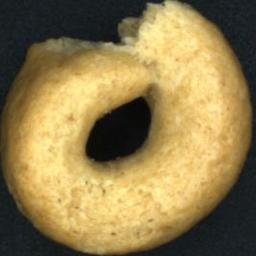

In [8]:
import random 
from PIL import Image 

random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem 
print(image_class)

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

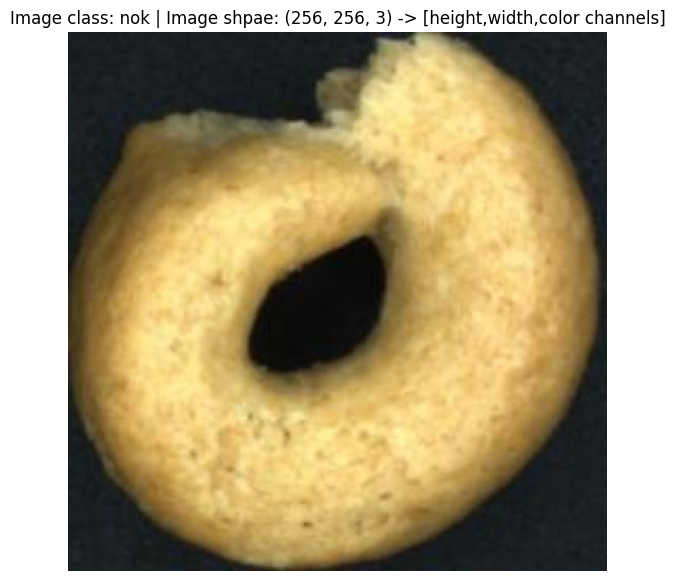

In [9]:
# Visualize using matplotlib 
import numpy as np 
import matplotlib.pyplot as plt 

img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shpae: {img_as_array.shape} -> [height,width,color channels]")
plt.axis(False)

# Transforming Data

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets , transforms  

In [11]:
data_transform = transforms.Compose([
    transforms.Resize(size = (128 , 128 )) , 
    # Flip the images randomely on the horizontal (Augmentation)
    transforms.RandomHorizontalFlip(p=0.5) , 
    # Turn the image into a torch.Tnesor
    transforms.ToTensor()
])

test_data_transform = transforms.Compose([
    transforms.Resize(size = (128 , 128 )) , 
    transforms.ToTensor()
])

In [12]:
data_transform(img).shape

torch.Size([3, 128, 128])

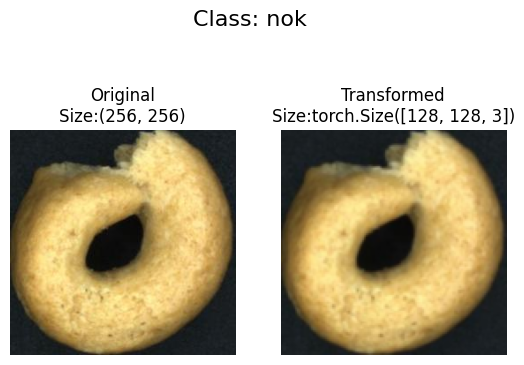

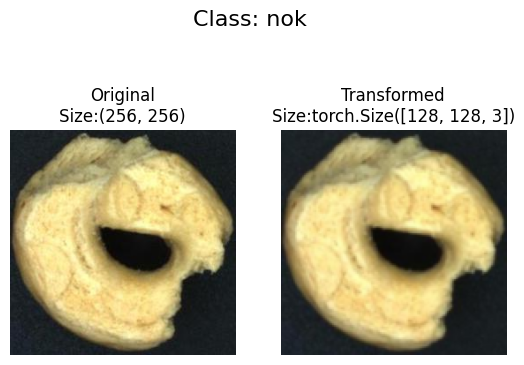

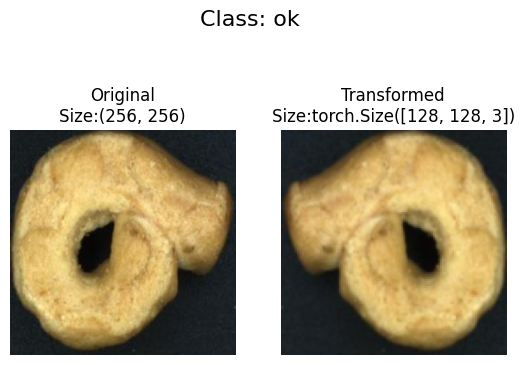

In [13]:
def plot_transformed_images(image_paths : list , transform , n=3 , seed=None) : 
    
    if seed : 
        random.seed(seed)
    random_image_paths = random.sample(image_paths , k = n  ) 
    for image_path in random_image_paths : 
        with Image.open(image_path ) as f : 
            fig ,ax = plt.subplots(nrows = 1 , ncols = 2 )
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize:{f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nSize:{transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class: {image_path.parent.stem}" , fontsize = 16)


plot_transformed_images(image_paths = image_path_list , transform = data_transform , n=3 , seed = 42)
    
        
    

# Loading image data using `ImageFolder`

In [14]:
from torchvision import datasets 
train_data = datasets.ImageFolder(root=train_dir ,
                                  transform=data_transform ,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir ,
                                  transform=test_data_transform )

train_data , test_data 

(Dataset ImageFolder
     Number of datapoints: 2600
     Root location: data/IndustryBiscuit_Folders/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 600
     Root location: data/IndustryBiscuit_Folders/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [15]:
class_names = train_data.classes
class_names

['nok', 'ok']

In [16]:
class_dict = train_data.class_to_idx
class_dict

{'nok': 0, 'ok': 1}

In [17]:
len(train_data) , len(test_data)

(2600, 600)

In [18]:
train_data.samples[0]

('data/IndustryBiscuit_Folders/train/nok/0001.jpg', 0)

In [19]:
train_data.targets[2000:2020]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [20]:
train_data[0]

(tensor([[[0.1098, 0.1216, 0.1137,  ..., 0.0941, 0.0902, 0.0941],
          [0.1020, 0.1059, 0.1020,  ..., 0.0980, 0.0902, 0.0902],
          [0.1176, 0.1098, 0.1020,  ..., 0.1059, 0.1059, 0.1020],
          ...,
          [0.1098, 0.1059, 0.1137,  ..., 0.0941, 0.1020, 0.1137],
          [0.1020, 0.1020, 0.1176,  ..., 0.0980, 0.1020, 0.1098],
          [0.1098, 0.1137, 0.1059,  ..., 0.0980, 0.1020, 0.1098]],
 
         [[0.1373, 0.1490, 0.1412,  ..., 0.1137, 0.1098, 0.1137],
          [0.1294, 0.1333, 0.1294,  ..., 0.1176, 0.1098, 0.1098],
          [0.1451, 0.1373, 0.1294,  ..., 0.1255, 0.1255, 0.1216],
          ...,
          [0.1412, 0.1373, 0.1451,  ..., 0.1137, 0.1216, 0.1333],
          [0.1333, 0.1333, 0.1490,  ..., 0.1176, 0.1216, 0.1294],
          [0.1412, 0.1451, 0.1373,  ..., 0.1176, 0.1216, 0.1294]],
 
         [[0.1686, 0.1804, 0.1725,  ..., 0.1255, 0.1216, 0.1255],
          [0.1608, 0.1647, 0.1608,  ..., 0.1294, 0.1216, 0.1216],
          [0.1765, 0.1686, 0.1608,  ...,

In [21]:
img , label = train_data[0][0] , train_data[0][1]
print(img.shape)
print(img.dtype)
print(label)
print(f"lable type {type(label)}")

torch.Size([3, 128, 128])
torch.float32
0
lable type <class 'int'>


In [22]:
class_names[label]

'nok'

torch.Size([3, 128, 128])
torch.Size([128, 128, 3])


Text(0.5, 1.0, 'nok')

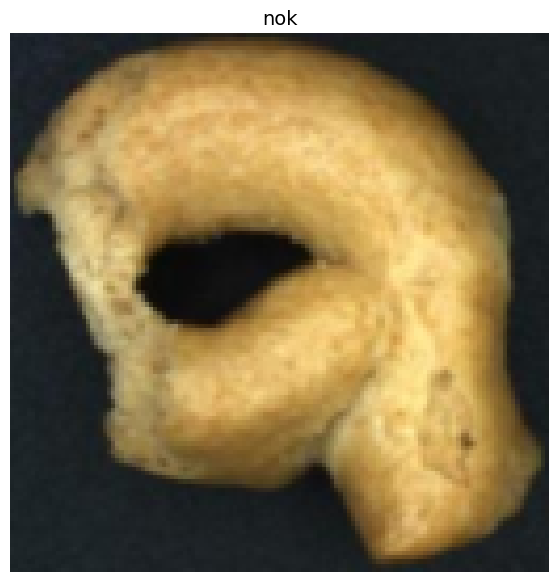

In [23]:
img_premute = img.permute(1,2,0)
print(img.shape)
print(img_premute.shape)
plt.figure(figsize=(10,7))
plt.imshow(img_premute)
plt.axis(False)
plt.title(class_names[label] , fontsize=14)

# Trun loaded images into `DataLoader`

In [24]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32 

train_dataloader = DataLoader(dataset= train_data ,
                              batch_size= BATCH_SIZE ,
                              num_workers=  1, #os.cpu_count() #number of cpus dedicated  
                              shuffle= True )

test_dataloader = DataLoader(dataset= test_data ,
                              batch_size= BATCH_SIZE ,
                              num_workers=  1, #os.cpu_count() 
                              shuffle= False )

train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1299369f0>,
 <torch.utils.data.dataloader.DataLoader at 0x118fd0bc0>)

In [25]:
len(train_dataloader) , len(test_dataloader) # len(train)/BATCH_SIZE


(82, 19)

In [26]:
img , label = next(iter(train_dataloader))
print(f"Image shape : {img.shape} ->[batch_size , color_channels , height , width]")
print(f"Label shape: {label.shape}")

Image shape : torch.Size([32, 3, 128, 128]) ->[batch_size , color_channels , height , width]
Label shape: torch.Size([32])


## Create a function to display random images

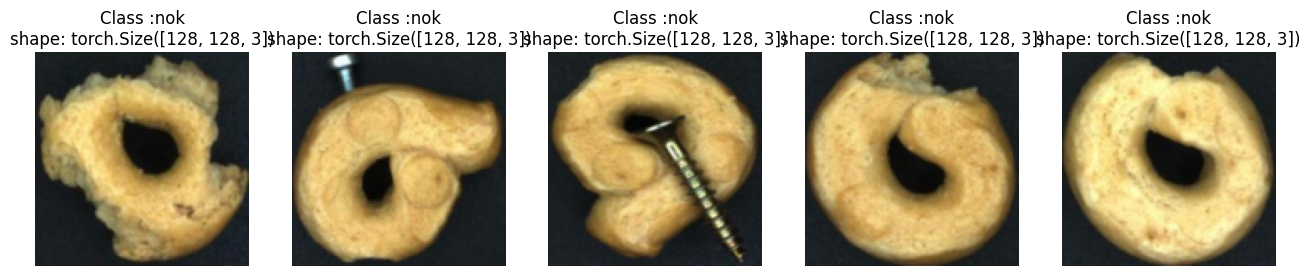

In [27]:
from typing import List


def display_random_images(dataset : torch.utils.data.Dataset ,
                          classes: List[str] = None ,
                          n: int = 10 ,
                          display_shape : bool = True ,
                          seed : int = None   ) : 
    if n >= 10 : 
        n = 10 
        display_shape = False 

    if seed : 
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)) , k = n )

    plt.figure(figsize=(16,8))
    
    for i , targ_sample in enumerate(random_samples_idx) : 
        targ_image , targ_label = dataset[targ_sample][0] , dataset[targ_sample][1]

        targ_image_permuted = targ_image.permute(1, 2, 0 )

        plt.subplot(1, n , i+1 )
        plt.imshow(targ_image_permuted)
        plt.axis(False)
        if classes : 
            title = f"Class :{classes[targ_label]}"
            if display_shape : 
               title = title + f"\nshape: {targ_image_permuted.shape}"
            plt.title(title)
        


display_random_images(dataset = train_data , classes=class_names , seed = None , display_shape = True , n=5 )


# Baseline : Model_0 

In [28]:

class TinyVGG(nn.Module) : 
    def __init__(self , input_shape : int , hidden_units : int , output_shape : int ) : 
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape , out_channels=hidden_units , kernel_size = 3 , stride = 1 , padding =0  ) , 
            nn.ReLU() , 
            nn.Conv2d(in_channels= hidden_units , out_channels=hidden_units , kernel_size = 3 , stride = 1 , padding =0  ) , 
            nn.ReLU() , 
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_units , out_channels=hidden_units , kernel_size = 3 , stride = 1 , padding =0  ) , 
            nn.ReLU() , 
            nn.Conv2d(in_channels= hidden_units , out_channels=hidden_units , kernel_size = 3 , stride = 1 , padding =0  ) , 
            nn.ReLU() , 
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten() , 
            nn.Linear(in_features = hidden_units * 29 * 29 , out_features = output_shape)
      
        )

    def forward(self , x ) : 
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))        
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x 



In [29]:

    
def train_step( model :  torch.nn.Module , 
                dataloader :  torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                optimizer : torch.optim.Optimizer , 
                accuracy_fn , 
                device : torch.device = device ) : 
    
    model.train()

    train_loss , train_acc = 0,  0
    
    for batch, (X,y) in enumerate(dataloader) : 
        
        X,y = X.to(device) , y.to(device)
        
        y_pred = model(X)
        
        loss = loss_fn(y_pred , y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true = y , y_pred = torch.softmax(y_pred, dim=1).argmax(dim=1) )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        # if batch % 400 == 0 : 
            # print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset )} samples . ")

    train_loss = train_loss/ len(dataloader)
    train_acc = train_acc /  len(dataloader)
    # print(f"\nTrain Loss:{train_loss:.5f} | Train Acc:{train_acc:.3f}" )

    return train_loss , train_acc


In [30]:

def test_step(  model :  torch.nn.Module , 
                dataloader :  torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                optimizer : torch.optim.Optimizer , 
                accuracy_fn , 
                device : torch.device = device ): 
    
    test_loss , test_acc = 0, 0 
    
    model.eval()
    
    with torch.inference_mode() : 
        for batch, (X_test, y_test) in enumerate(dataloader): 
            X_test , y_test = X_test.to(device) , y_test.to(device)
            test_pred = model(X_test)

            test_loss += loss_fn(test_pred,y_test).item()
            test_pred_labels = test_pred.argmax(dim=1)
            test_acc += ((test_pred_labels == y_test).sum().item()/len(test_pred_labels))
            # test_acc += accuracy_fn(y_true= y_test , y_pred = torch.softmax(test_pred, dim=1).argmax(dim=1) )

        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        # print(f"\nTest Loss: {test_loss:.5f} | Test Acc: {test_acc:.3f}")

    return test_loss , test_acc


In [34]:
import pathlib
torch.manual_seed(42)


MODEL_SAVE_PATH = pathlib.Path("models") / "tinyvgg-classification-model.pth"

model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names))
model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH, map_location=device))
model_0.to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8410, out_features=2, bias=True)
  )
)

In [35]:

image_batch , label_batch = next(iter(train_dataloader))
image_batch.shape , label_batch.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [36]:
model_0(image_batch.to(device))

tensor([[   9.8496,   -9.7671],
        [  -2.5836,    2.8689],
        [   6.9142,   -6.6434],
        [  -5.8629,    6.0570],
        [  -5.9008,    6.0799],
        [  10.5088,  -10.3860],
        [  -1.0466,    1.0670],
        [  -5.9730,    6.3041],
        [  -4.2178,    4.2693],
        [  -3.8759,    4.2243],
        [  -2.2283,    2.2496],
        [  -3.5892,    3.5158],
        [  -2.6548,    2.8474],
        [  -1.7169,    1.8341],
        [  -1.8511,    1.7976],
        [  -0.9108,    1.1776],
        [  -5.5360,    5.6670],
        [  -4.5796,    4.7901],
        [  -3.4697,    3.4559],
        [  -1.1316,    1.1419],
        [  -3.3609,    3.4439],
        [  22.2393,  -22.1162],
        [  -5.4641,    5.6166],
        [  -2.5813,    2.7750],
        [   4.4196,   -4.4641],
        [  -2.1170,    2.2013],
        [  -4.6882,    4.6290],
        [  13.0213,  -12.9613],
        [ 163.1447, -162.9897],
        [   9.5870,   -9.5873],
        [  -4.0304,    4.0137],
        

In [37]:
## torchinfo 

try : 
    import torchinfo 
except : 
    !pip install torchinfo 
    import torchinfo 

from torchinfo import summary 

summary(model_0 , input_size =[1,3,128,128])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 2]                    --
├─Sequential: 1-1                        [1, 10, 62, 62]           --
│    └─Conv2d: 2-1                       [1, 10, 126, 126]         280
│    └─ReLU: 2-2                         [1, 10, 126, 126]         --
│    └─Conv2d: 2-3                       [1, 10, 124, 124]         910
│    └─ReLU: 2-4                         [1, 10, 124, 124]         --
│    └─MaxPool2d: 2-5                    [1, 10, 62, 62]           --
├─Sequential: 1-2                        [1, 10, 29, 29]           --
│    └─Conv2d: 2-6                       [1, 10, 60, 60]           910
│    └─ReLU: 2-7                         [1, 10, 60, 60]           --
│    └─Conv2d: 2-8                       [1, 10, 58, 58]           910
│    └─ReLU: 2-9                         [1, 10, 58, 58]           --
│    └─MaxPool2d: 2-10                   [1, 10, 29, 29]           --
├─Sequentia

In [44]:
torch.manual_seed(42)

def eval_model( model : torch.nn.Module , 
                data_loader : torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                accuracy_fn , 
                 device : torch.device = device ) : 
    loss , acc = 0 , 0 
    model.to(device)
    model.eval()
    with torch.inference_mode() : 
        for X, y in data_loader : 
            X , y = X.to(device) , y.to(device)
            y_pred = model(X)
            loss+= loss_fn(y_pred , y)
            acc+= accuracy_fn(y_true= y , y_pred = y_pred.argmax(dim=1))
        loss/=len(data_loader)
        acc/=len(data_loader)


        return {"model_name" : model.__class__.__name__ , 
                 "model_loss" : loss.item() , 
                 "model_acc" : acc}



model_0_results = eval_model(model= model_0 
                             , data_loader = test_dataloader 
                             , loss_fn = loss_fn 
                             , accuracy_fn = accuracy_fn )
model_0_results

{'model_name': 'TinyVGG',
 'model_loss': 0.059020232409238815,
 'model_acc': 0.9802631578947368}

In [45]:
def make_predictions(model: torch.nn.Module , 
                     data : list , 
                     device : torch.device = device ) : 
    pred_probs =[]
    model.to(device)
    model.eval()

    with torch.inference_mode()  : 
        for sample in data : 
            sample = sample.unsqueeze(0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit, dim=1 ).argmax(dim=1).squeeze(0)
            pred_probs.append(pred_prob.cpu())
            
    return torch.stack(pred_probs)
    


In [46]:
import random 
# random.seed(42)
test_samples = []
test_labels =[]

for sample , label in random.sample(list(test_data) , k = 9 ) : 
    test_samples.append(sample)
    test_labels.append(label)

In [47]:
pred_probs = make_predictions(model = model_0 , data = test_samples )
pred_probs

tensor([1, 0, 1, 0, 0, 0, 0, 0, 1])

In [48]:
test_labels

[1, 0, 1, 0, 0, 0, 0, 0, 1]

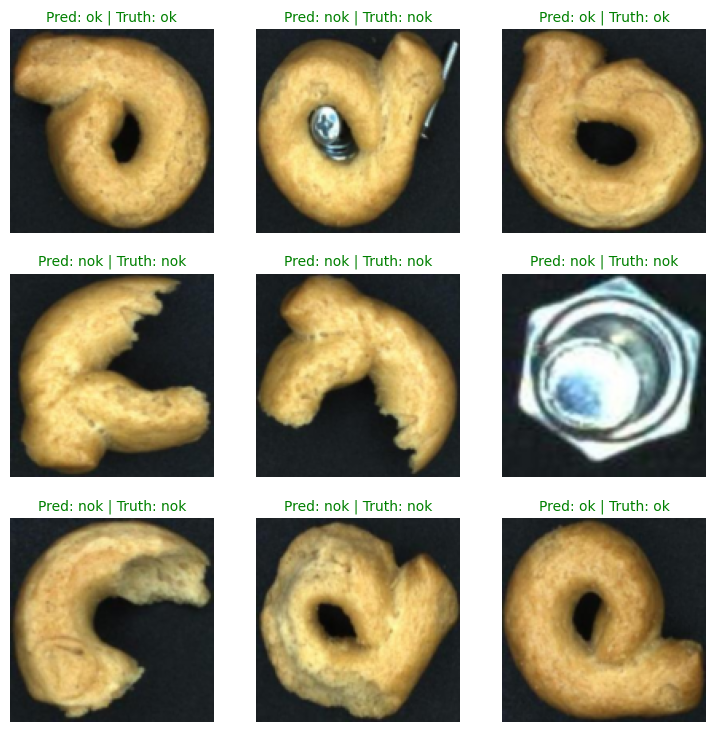

In [49]:
plt.figure(figsize=(9,9))
nrows = 3 
ncols = 3 

for i, sample in enumerate(test_samples) : 
    plt.subplot(nrows , ncols , i+1 )
    plt.imshow(sample.squeeze().permute(1, 2, 0))
    pred_label = class_names[pred_probs[i]]
    truth_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    if pred_label == truth_label : 
        plt.title(title_text , fontsize = 10 , c="g")
    else : 
        plt.title(title_text , fontsize = 10 , c="r")

    

    plt.axis(False)

In [50]:
from tqdm import tqdm

y_preds = []
model_0.eval()
with torch.inference_mode() : 
    for X,y in   tqdm(test_dataloader,desc="Making predictions...") : 
        X , y = X.to(device) , y.to(device)
        y_logits = model_0(X)
        y_pred = torch.softmax(y_logits, dim=1 ).argmax(dim=1).squeeze(0)
        y_preds.append(y_pred)

print(len(y_preds[0]))
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...: 100%|██████████████████████████████████████████████████████████████████████| 19/19 [00:07<00:00,  2.65it/s]

32


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

/var/folders/x0/4xyb0l7x6jq6l77tkdkd_t0w0000gn/T/ipykernel_2973/4265044712.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred_tensor = torch.tensor(y_pred_tensor).to(device)


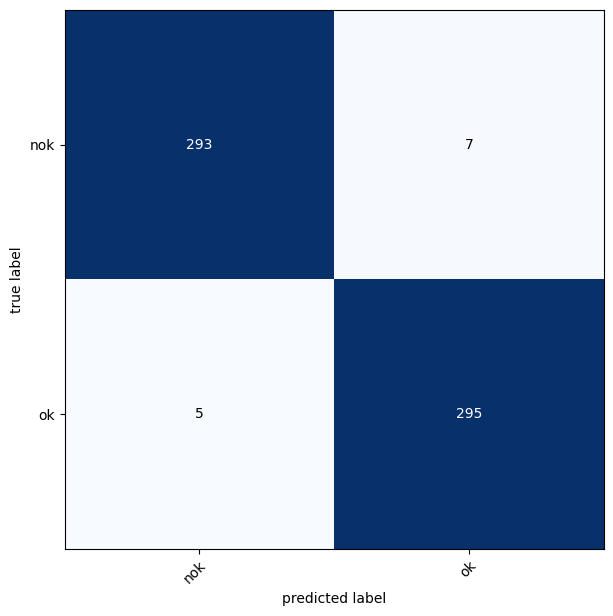

In [51]:
from torchmetrics import ConfusionMatrix 
from mlxtend.plotting import plot_confusion_matrix 
device = "cpu"
# setup confusion matrix 
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names)).to(device)
y_pred_tensor = torch.tensor(y_pred_tensor).to(device)
targets = torch.tensor(test_data.targets).to(device)

confmat_tensor = confmat(preds = y_pred_tensor , target = targets )

#plot confusion matrix 
fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy() , 
    class_names = class_names , 
    figsize = (10,7)
)
